## Teoría base (cómo leer los bloques de código)

Para cada bloque importante, pregunta siempre:

1. **Modelo**: ¿qué función aproxima?
2. **Pérdida**: ¿qué error penaliza?
3. **Optimizador**: ¿cómo actualiza parámetros?

Objetivo general:
$$
\min_\theta\,\mathcal{L}(f_\theta(x),y)
$$

En práctica, verás el ciclo: `forward` → `loss` → `backward` → `step`. Es la rutina central del entrenamiento.

# Librerías

## Guía de lectura (formato común)

En este cuaderno seguiremos siempre este patrón:
1. **Idea clave** (intuición para principiantes).
2. **Fórmula** (versión matemática mínima necesaria).
3. **Qué observar en la salida** (cómo interpretar gráficos/resultados).

**Notación común del curso:**
- $x$: entrada.
- $\theta$: parámetros del modelo.
- $\hat y = f_\theta(x)$: predicción.
- $\mathcal{L}$: función de pérdida.
- $\eta$: learning rate.

**Objetivo de este notebook:** interiorizar los 3 ingredientes del entrenamiento (modelo, pérdida y optimizador) y su bucle de trabajo.

## Marco teórico: los 3 ingredientes del entrenamiento

En una red neuronal supervisada siempre aparecen estos 3 bloques:

1. **Modelo** $f_\theta(x)$: transforma entrada $x$ en salida.
2. **Función de pérdida** $\mathcal{L}(\hat y, y)$: mide error entre predicción y etiqueta real.
3. **Optimizador**: actualiza $\theta$ para reducir la pérdida.

Objetivo global:
$$
\theta^*=\arg\min_\theta \frac{1}{N}\sum_{i=1}^{N}\mathcal{L}(f_\theta(x_i),y_i)
$$

En este cuaderno lo verás sobre Iris (3 clases).

In [1]:
import torch
import torch.nn as nn # neural network
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
from torchviz import make_dot # visualización de grafos computacionales

# Iris dataset

In [2]:
# En PyTorch, los datasets deben heredar de torch.utils.data.Dataset
class IrisDataset(Dataset):
    # Inicializamos el dataset cargando los datos
    def __init__(self):
        data = load_iris()
        self.X = torch.tensor(
            data.data, dtype=torch.float32
        )  # (150, 4)
        self.y = torch.tensor(
            data.target, dtype=torch.long
        )  # (150,)

    # PyTorch necesita saber el tamaño del dataset
    def __len__(self):
        return self.X.shape[0]
    
    # PyTorch necesita poder indexar el dataset
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [3]:
full_iris_dataset = IrisDataset()

In [4]:
# ejemplos de muestras
for i in [1, 50, 100]:
    x, y = full_iris_dataset[i]
    print(f"Muestra {i}: x = {x}, y = {y}")

Muestra 1: x = tensor([4.9000, 3.0000, 1.4000, 0.2000]), y = 0
Muestra 50: x = tensor([7.0000, 3.2000, 4.7000, 1.4000]), y = 1
Muestra 100: x = tensor([6.3000, 3.3000, 6.0000, 2.5000]), y = 2


In [5]:
len(full_iris_dataset)

150

# Definición de la red

### Modelo lineal para clasificación multiclase

Una capa lineal calcula:
$$
z = Wx + b
$$

- $x\in\mathbb{R}^4$ (features de Iris),
- $z\in\mathbb{R}^3$ (logits para 3 clases).

Los logits **no** son probabilidades todavía. `CrossEntropyLoss` aplica internamente `log_softmax`, por eso no ponemos `softmax` en `forward`.

In [6]:
class IrisRed(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.fc1(x)   # (B, 3)
        return h
    
# el softmax no se suele incluir en el modelo porque
# 1) la función de pérdida CrossEntropyLoss ya lo incluye
# 2) y porque en inferencia se suele usar argmax (selección de la clase con mayor puntuación)

# Grafo computacional

### De logits a probabilidades y pérdida

El modelo produce logits $z=(z_1,\dots,z_K)$. La probabilidad por clase se obtiene con softmax:
$$
p_k=\frac{e^{z_k}}{\sum_j e^{z_j}}
$$

Para la clase correcta $y$, la cross-entropy es:
$$
\mathcal{L}_{CE}=-\log p_y
$$

Conclusión intuitiva:
- si el modelo asigna alta probabilidad a la clase correcta, la pérdida es baja;
- si asigna baja probabilidad, la pérdida es alta.

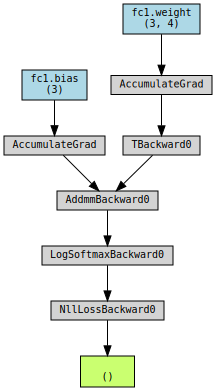

In [7]:
# Instanciamos el modelo y el loss
# En PyTorch, el loss y el modelo suelen ser instanciados por separado
model = IrisRed()
criterion = nn.CrossEntropyLoss()

# Input dummy (batch size = 5)
x = torch.randn(5, 4, requires_grad=False)

# Forward
y = model(x)
# Loss
target = torch.tensor([1, 0, 2, 1, 2])  # clase verdadera
loss = criterion(y, target)


# Crear grafo computacional
dot = make_dot(loss, params=dict(model.named_parameters()))

# Mostrar o guardar
dot

In [8]:
# ejemplo numérico rápido logits -> probabilidades -> loss
x_sample, y_sample = full_iris_dataset[0]
logits = model(x_sample.unsqueeze(0))  # (1, 3)
probs = torch.softmax(logits, dim=-1)
loss_sample = criterion(logits, torch.tensor([y_sample]))

print("Clase real:", int(y_sample))
print("Logits:", logits.detach().numpy().round(4))
print("Probabilidades softmax:", probs.detach().numpy().round(4))
print("CrossEntropyLoss:", float(loss_sample))

Clase real: 0
Logits: [[3.2048 1.4826 0.0697]]
Probabilidades softmax: [[0.8182 0.1462 0.0356]]
CrossEntropyLoss: 0.20062337815761566


/tmp/ipykernel_66150/3305335415.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("CrossEntropyLoss:", float(loss_sample))


# Stochastic Gradient Descent, dividr en batches

### ¿Por qué mini-batches (SGD)?

En lugar de usar todo el dataset en cada paso, usamos lotes de tamaño $B$.

Pérdida en batch:
$$
\mathcal{L}_B(\theta)=\frac{1}{B}\sum_{i=1}^{B}\mathcal{L}(f_\theta(x_i),y_i)
$$

Actualización típica:
$$
\theta \leftarrow \theta - \eta\,\nabla_\theta \mathcal{L}_B(\theta)
$$

Ventajas:
- menos memoria,
- más rápido por iteración,
- el ruido del gradiente ayuda a escapar de mínimos pobres.

In [9]:
# esta función devuelve un iterador sobre batches
dataloader = DataLoader(full_iris_dataset, batch_size=16, shuffle=True)
# por otro lado, la red se ha definido para procesar batches de datos

# Juntamos los tres ingredientes

### Bucle estándar de entrenamiento (plantilla)

Cada iteración sigue este patrón:
1. `optimizer.zero_grad()` → limpia gradientes antiguos.
2. `logits = model(xB)` → **forward**.
3. `loss = criterion(logits, yB)` → cálculo de error.
4. `loss.backward()` → **backpropagation**.
5. `optimizer.step()` → actualización de parámetros.

Esta plantilla se reutiliza en prácticamente todos los proyectos de deep learning.

In [10]:
# instanciar modelo, loss y optimizador
# si se dispone de GPU, mover el modelo a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# la red se inicializa a pesos aleatorios cada vez que se instancia
model = IrisRed().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

In [11]:
num_epochs = 100
# durante un número de epochs
for epoch in range(1, num_epochs + 1):
    # poner el modelo en modo entrenamiento
    model.train()
    # para llevar la cuenta del loss
    running_loss = 0.0
    n_seen = 0
    for xB, yB in dataloader:
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()      # reset gradientes
        logits = model(xB)         # forward
        loss = criterion(logits, yB)
        loss.backward()            # backward
        optimizer.step()           # update
        running_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
        n_seen += xB.size(0)           # para llevar la cuenta del loss
    epoch_loss = running_loss / n_seen # loss medio en la epoch
    print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f}") # reportamos el loss

Epoch 001 | train_loss = 1.0637
Epoch 002 | train_loss = 0.8690
Epoch 003 | train_loss = 0.8312
Epoch 004 | train_loss = 0.7948
Epoch 005 | train_loss = 0.7663
Epoch 006 | train_loss = 0.7429
Epoch 007 | train_loss = 0.7228
Epoch 008 | train_loss = 0.6978
Epoch 009 | train_loss = 0.6793
Epoch 010 | train_loss = 0.6630
Epoch 011 | train_loss = 0.6499
Epoch 012 | train_loss = 0.6330
Epoch 013 | train_loss = 0.6206
Epoch 014 | train_loss = 0.6042
Epoch 015 | train_loss = 0.6032
Epoch 016 | train_loss = 0.5860
Epoch 017 | train_loss = 0.5751
Epoch 018 | train_loss = 0.5656
Epoch 019 | train_loss = 0.5575
Epoch 020 | train_loss = 0.5537
Epoch 021 | train_loss = 0.5438
Epoch 022 | train_loss = 0.5386
Epoch 023 | train_loss = 0.5306
Epoch 024 | train_loss = 0.5257
Epoch 025 | train_loss = 0.5196
Epoch 026 | train_loss = 0.5142
Epoch 027 | train_loss = 0.5070
Epoch 028 | train_loss = 0.5062
Epoch 029 | train_loss = 0.5036
Epoch 030 | train_loss = 0.4921
Epoch 031 | train_loss = 0.4926
Epoch 03

# Ejercicio

Divide el dataset en train y test, y entrena el modelo durante 100 epochs. Evalúa el accuracy en el conjunto de test.
- `torch.utils.data.random_split`
- `torch.argmax` con el parámetro `dim` (indica la dimensión a reducir). `dim` es equivalente a `axis` en NumPy. Seguntamente tengáis que usar `dim=1` para reducir la dimensión de las clases.

Recuerda poner el modelo en modo evaluación con `model.eval()` cuando evalúes en el conjunto de test.

In [12]:
from torch.utils.data import random_split

# Dividimos: 70% para entrenar y 30% para test
train_size = 0.7
test_size = 0.3
train_dataset, test_dataset = random_split(full_iris_dataset, [int(len(full_iris_dataset) * train_size), int(len(full_iris_dataset) * test_size)])

# Creamos los DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Creamos una semilla para reproducibilidad
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed = 42
set_seed(seed)
print('Seed set with value', seed)

Seed set with value 42


In [13]:
model = IrisRed().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

num_epochs = 100
# durante un número de epochs
for epoch in range(1, num_epochs + 1):
    model.train()
    for xB, yB in train_loader:
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xB), yB)
        loss.backward()
        optimizer.step()

# Evaluación del modelo en el conjunto de test
model.eval() # Modo evaluación
correctas = 0
total = 0

with torch.no_grad(): # Desactivamos gradientes para ahorrar memoria
    for xB, yB in test_loader:
        xB, yB = xB.to(device), yB.to(device)
        outputs = model(xB)
        
        # Obtenemos la clase con mayor puntuación (argmax)
        predicciones = torch.argmax(outputs, dim=1)
        
        total += yB.size(0)
        correctas += (predicciones == yB).sum().item()

accuracy = 100 * correctas / total
print(f"\nAccuracy en el conjunto de TEST: {accuracy:.2f}%")


Accuracy en el conjunto de TEST: 95.56%
